In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df_2mm_baseline = pd.read_csv("./rn222_repetition_runs/rn222_2mmfully_10reps_10k/outputs/2mm_2mm_10k_baseline_rep01_photon_boundaries.csv")
df_2mm_40_loc = pd.read_csv("./rn222_repetition_runs/rn222_2mmfully_10reps_10k/outputs/2mm_2mm_10k_40_Rn222_loc_rep01_photon_boundaries.csv")
df_2mm_50_diff = pd.read_csv("./rn222_repetition_runs/rn222_2mmfully_10reps_10k/outputs/2mm_2mm_10k_50diffRn222_rep01_photon_boundaries.csv")

In [ ]:
def plot_photons_vs_distance(df, get_hist=False, title=None, panel_coord = "Y"):    
    other_coords = {'Y': ['x_mm', 'z_mm'],
                    'X': ['y_mm', 'z_mm'],
                    'Z': ['x_mm', 'y_mm']}
    bins=np.linspace(-1500, 1500, 60)
    fig, axs = plt.subplots(3, sharex=True, figsize=(8,5))
    fig.suptitle(title)
    xpos= df[(df['volumeName']==f"physPhotonDetectorPos{panel_coord}") & (df['boundary']=='enter')][other_coords[panel_coord][0]]
    xneg= df[(df['volumeName']==f"physPhotonDetectorNeg{panel_coord}") & (df['boundary']=='enter')][other_coords[panel_coord][0]]
    zpos = df[(df['volumeName']==f"physPhotonDetectorPos{panel_coord}") & (df['boundary']=='enter')][other_coords[panel_coord][0]]
    zneg = df[(df['volumeName']==f"physPhotonDetectorNeg{panel_coord}") & (df['boundary']=='enter')][other_coords[panel_coord][0]]
    axs[0].hist2d(zpos.to_numpy(), xpos.to_numpy(), bins=bins, cmap='Oranges')
    axs[0].set_ylabel('x pos [mm]')
    axs[0].set_ylim((-500,500))
    axs[0].text(x=1250,y=350, s='PosY', fontsize='medium')

    axs[1].hist(zneg, bins=bins, histtype=u'step', label='Y panel - below', linewidth=2)
    axs[1].hist(zpos, bins=bins, histtype=u'step', label='Y panel - above', linewidth=2)
    axs[1].legend(loc='upper right', fontsize='small')
    axs[1].set_ylabel('counts')

    axs[2].hist2d(zneg.to_numpy(), xneg.to_numpy(), bins=bins, cmap='Blues')
    axs[2].set_ylabel('x pos [mm]')
    axs[2].set_ylim((-500,500))
    axs[2].text(x=1250,y=350, s='NegY', fontsize='medium')

    plt.xlabel("z pos [mm]")

    plt.show()
    if get_hist:
        return zneg, zpos

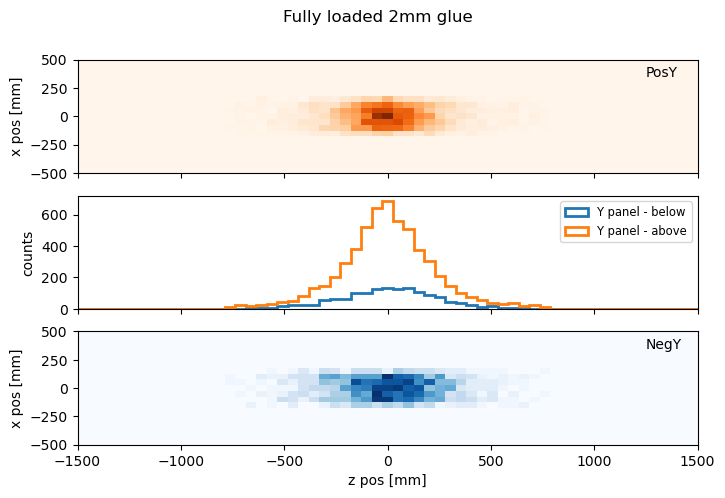

In [11]:
zneg_base, zpos_base = plot_photons_vs_distance(df_2mm_baseline, title='Fully loaded 2mm glue', get_hist=True)

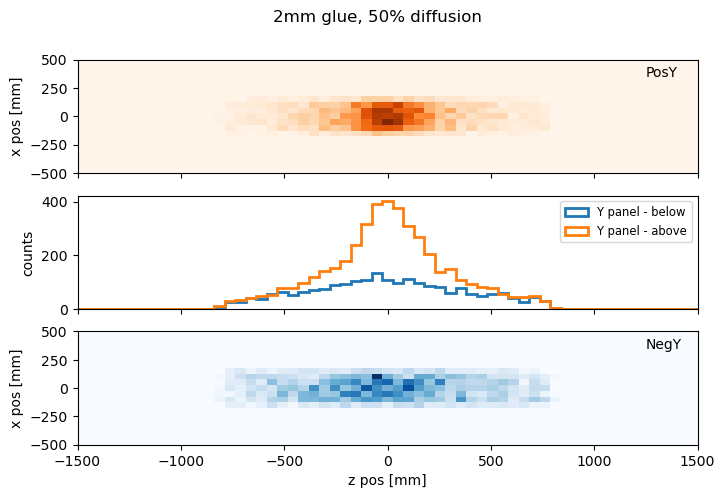

In [12]:
zneg_diff50, zpos_diff50 = plot_photons_vs_distance(df_2mm_50_diff, title='2mm glue, 50% diffusion', get_hist=True)

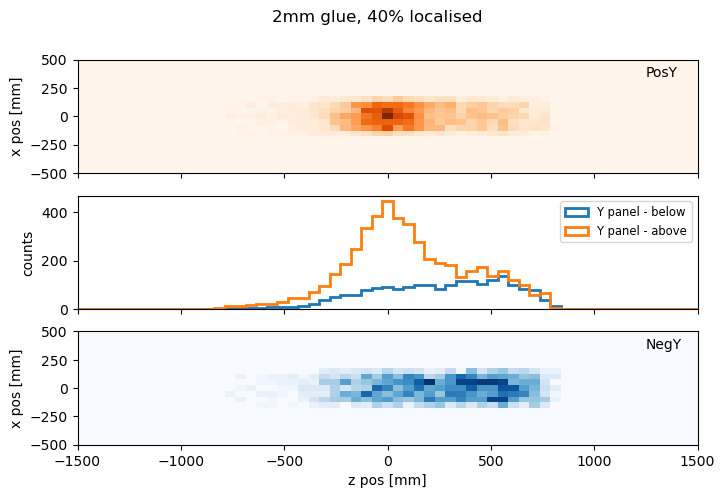

In [13]:
zneg_diff40, zpos_diff40 = plot_photons_vs_distance(df_2mm_40_loc, title='2mm glue, 40% localised', get_hist=True)

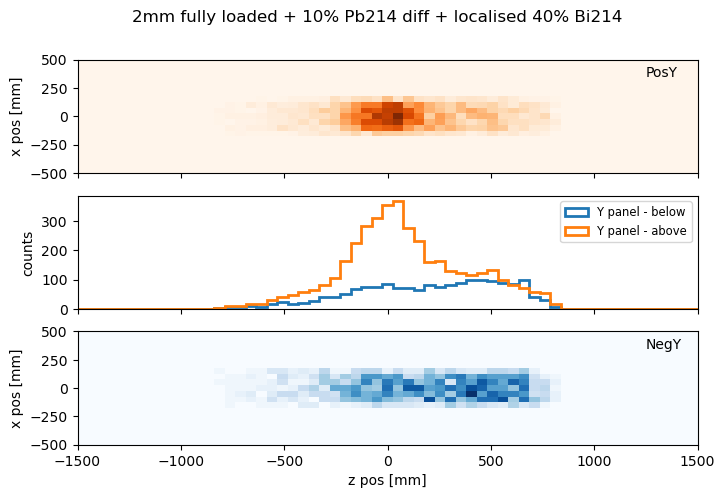

In [14]:
df_2mm_fully_10k_10_40 = pd.read_csv("./PhotonDetector/build/2mm_2mm_10k_1040_photon_boundaries.csv")
zneg_diff1040, zpos_diff1040 = plot_photons_vs_distance(df_2mm_fully_10k_10_40, get_hist=True, title='2mm fully loaded + 10% Pb214 diff + localised 40% Bi214')

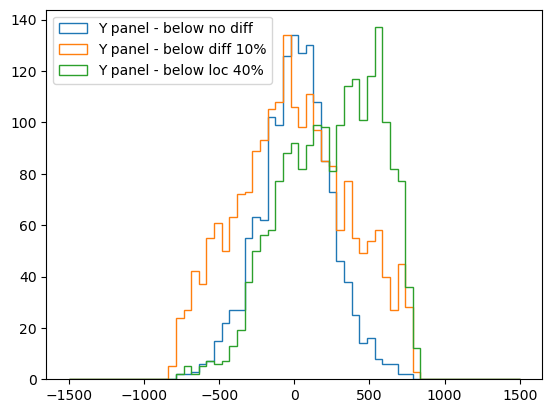

In [16]:
plt.figure()
bins=np.linspace(-1500, 1500, 60)
plt.hist(zneg_base, bins=bins, histtype=u'step', label='Y panel - below no diff', linewidth=1)
plt.hist(zneg_diff50, bins=bins, histtype=u'step', label='Y panel - below diff 10%', linewidth=1)
plt.hist(zneg_diff40, bins=bins, histtype=u'step', label='Y panel - below loc 40%', linewidth=1)
plt.legend()
plt.show()

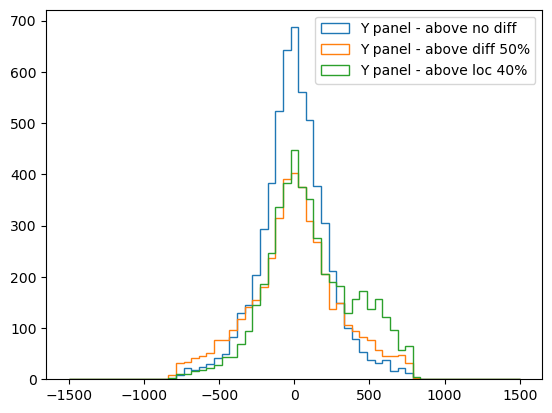

In [17]:
plt.figure()
bins=np.linspace(-1500, 1500, 60)
plt.hist(zpos_base, bins=bins, histtype=u'step', label='Y panel - above no diff', linewidth=1)
plt.hist(zpos_diff50, bins=bins, histtype=u'step', label='Y panel - above diff 50%', linewidth=1)
plt.hist(zpos_diff40, bins=bins, histtype=u'step', label='Y panel - above loc 40%', linewidth=1)
plt.legend()
plt.show()

In [88]:
df_2mm_fully_10k = pd.read_csv("./PhotonDetector/build/2mm_2mm_10k_30_20_photon_boundaries.csv")


In [89]:
def leakage_region(df,  panel='physPhotonDetectorPosY', coord_range=(-600, -800), coord='z_mm'):
    df[(df['volumeName']==panel) 
                 & (df['boundary']=='enter') 
                 & (df[coord] <= coord_range[0]) & (df[coord] >= coord_range[1])
                 ]['z_mm'].hist(histtype=u'step', bins=np.linspace(coord_range[1]-100, coord_range[0]+100, 40))


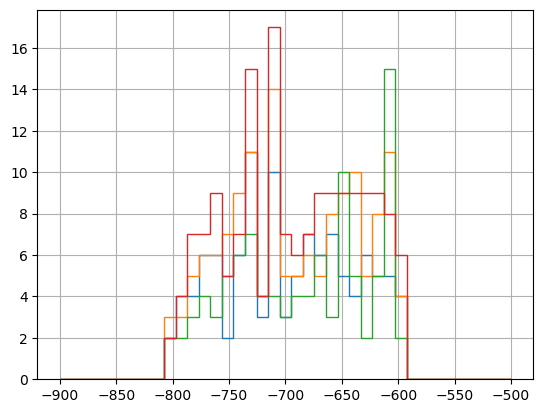

In [90]:
plt.figure()
leakage_region(df_2mm_fully_10k)
leakage_region(df_2mm_fully_10k_214p_diff_50)
leakage_region(df_2mm_fully_10k_214p_diff_10)
leakage_region(df_2mm_fully_10k_214p_diff_99)